# Kudge Solver/Judge Difficulty Comparison

Load Kudge K-factor item difficulty JSONs and keep each item's per-model scores. `kudge_challenge` is treated as solver-side; `kudge_judge` is treated as judge-side.


In [1]:
from pathlib import Path
import json

import pandas as pd
from scipy.stats import spearmanr
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 240)


## Choose K And Resolve Paths


In [2]:
MODEL_SELECTION_METRIC = "loss"  # lower held-out log loss is better
K = None  # set below from model selection



def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "K-Factor").exists() and (candidate / "benchmarks").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root containing K-Factor/ and benchmarks/")


REPO_ROOT = find_repo_root()
print(f"Repo root: {REPO_ROOT}")

solver_json_path = REPO_ROOT / "K-Factor" / "results" / "kudge_challenge" / "kudge_challenge_kfactor_item_difficulties_with_laplace_uncertainty.json"
judge_json_path = REPO_ROOT / "K-Factor" / "results" / "kudge_judge" / "kudge_judge_kfactor_item_difficulties_with_laplace_uncertainty.json"
solver_fit_summary_path = REPO_ROOT / "K-Factor" / "results" / "kudge_challenge" / "kudge_challenge_kfactor_fit_summary.csv"
judge_fit_summary_path = REPO_ROOT / "K-Factor" / "results" / "kudge_judge" / "kudge_judge_kfactor_fit_summary.csv"

out_dir = REPO_ROOT / "K-Factor" / "results" / "kudge_solver_judge_comparison"
out_dir.mkdir(parents=True, exist_ok=True)

for path in [solver_json_path, judge_json_path, solver_fit_summary_path, judge_fit_summary_path]:
    print(path.relative_to(REPO_ROOT), path.exists())


Repo root: /Users/dkoffical/Documents/GitHub/cs321m_project
K-Factor/results/kudge_challenge/kudge_challenge_kfactor_item_difficulties_with_laplace_uncertainty.json True
K-Factor/results/kudge_judge/kudge_judge_kfactor_item_difficulties_with_laplace_uncertainty.json True
K-Factor/results/kudge_challenge/kudge_challenge_kfactor_fit_summary.csv True
K-Factor/results/kudge_judge/kudge_judge_kfactor_fit_summary.csv True


## Fit Summaries


In [3]:
solver_fit_summary = pd.read_csv(solver_fit_summary_path)
judge_fit_summary = pd.read_csv(judge_fit_summary_path)

def choose_best_k(summary, metric="loss"):
    if metric == "loss":
        sort_cols = [c for c in ["loss", "brier", "ece", "auc"] if c in summary.columns]
        ascending = [True, True, True, False][:len(sort_cols)]
        return summary.sort_values(sort_cols, ascending=ascending).iloc[0]
    if metric == "auc":
        return summary.sort_values(["auc", "ece", "loss"], ascending=[False, True, True]).iloc[0]
    raise ValueError(f"Unknown model-selection metric: {metric}")

solver_best = choose_best_k(solver_fit_summary, MODEL_SELECTION_METRIC)
judge_best = choose_best_k(judge_fit_summary, MODEL_SELECTION_METRIC)
solver_selected_k = int(solver_best["k"])
judge_selected_k = int(judge_best["k"])
if solver_selected_k != judge_selected_k:
    raise ValueError(
        f"This notebook expects shared K, but loss selected solver K={solver_selected_k}, judge K={judge_selected_k}."
    )
K = solver_selected_k

print(f"Model selection metric: held-out {MODEL_SELECTION_METRIC}")
print(f"Solver-side best k: k={solver_selected_k}")
print(f"Judge-side best k:  k={judge_selected_k}")
print(f"Currently loading K={K}")

print()
print("Solver fit summary")
display(solver_fit_summary.round(4))

print("Judge fit summary")
display(judge_fit_summary.round(4))

solver_fit_summary.to_csv(out_dir / "kudge_solver_kfactor_fit_summary.csv", index=False)
judge_fit_summary.to_csv(out_dir / "kudge_judge_kfactor_fit_summary.csv", index=False)


Model selection metric: held-out loss
Solver-side best k: k=1
Judge-side best k:  k=1
Currently loading K=1

Solver fit summary


,k,loss,loss_std,auc,auc_std,log_likelihood,log_likelihood_std,brier,brier_std,ece,ece_std,final_train_loss,final_train_auc,final_train_log_likelihood,final_train_brier,final_train_ece
0,1,0.9203,NaN,0.7358,NaN,-0.9203,NaN,0.1817,NaN,0.1219,NaN,0.3019,0.9216,-0.3019,0.1012,0.0253
1,2,1.6651,NaN,0.6610,NaN,-1.6651,NaN,0.2299,NaN,0.2001,NaN,0.2169,0.9511,-0.2168,0.0706,0.0220


Judge fit summary


,k,loss,loss_std,auc,auc_std,log_likelihood,log_likelihood_std,brier,brier_std,ece,ece_std,final_train_loss,final_train_auc,final_train_log_likelihood,final_train_brier,final_train_ece
0,1,0.9833,NaN,0.6488,NaN,-0.9833,NaN,0.2209,NaN,0.1483,NaN,0.3694,0.8420,-0.3693,0.1257,0.0270
1,2,1.7176,NaN,0.6307,NaN,-1.7176,NaN,0.2637,NaN,0.2242,NaN,0.2667,0.8878,-0.2667,0.0888,0.0284


## Load Item Difficulties And Scores


In [4]:
def load_kfactor_fit(json_path, k, score_col):
    with open(json_path) as f:
        payload = json.load(f)

    fit_key = f"k{k}"
    if fit_key not in payload["fits"]:
        raise KeyError(f"{json_path} does not contain {fit_key}; available={list(payload['fits'])}")

    df = pd.DataFrame(payload["fits"][fit_key])
    df["item_id"] = df["item_id"].astype(str)
    df = df.rename(columns={"scores": score_col})
    return df, payload


solver_items, solver_payload = load_kfactor_fit(solver_json_path, K, "solver_scores")
judge_items, judge_payload = load_kfactor_fit(judge_json_path, K, "judge_scores")

print(f"solver_items: {solver_items.shape}")
print(f"judge_items:  {judge_items.shape}")

print()
print("Solver columns:")
print(list(solver_items.columns))

print()
print("Judge columns:")
print(list(judge_items.columns))


solver_items.to_csv(out_dir / f"kudge_k{K}_solver_items.csv", index=False)
judge_items.to_csv(out_dir / f"kudge_k{K}_judge_items.csv", index=False)
solver_items.to_json(out_dir / f"kudge_k{K}_solver_items.json", orient="records", indent=2, force_ascii=False)
judge_items.to_json(out_dir / f"kudge_k{K}_judge_items.json", orient="records", indent=2, force_ascii=False)


solver_items: (381, 17)
judge_items:  (381, 17)

Solver columns:
['item_id', 'difficulty', 'difficulty_centered', 'easiness_z', 'loading_factor_1', 'dominant_factor', 'item_id_meta', 'subset', 'gold', 'prompt', 'chosen', 'rejected', 'difficulty_laplace_se', 'difficulty_centered_laplace_se', 'difficulty_centered_laplace_lo', 'difficulty_centered_laplace_hi', 'solver_scores']

Judge columns:
['item_id', 'difficulty', 'difficulty_centered', 'easiness_z', 'loading_factor_1', 'dominant_factor', 'item_id_meta', 'subset', 'gold', 'prompt', 'chosen', 'rejected', 'difficulty_laplace_se', 'difficulty_centered_laplace_se', 'difficulty_centered_laplace_lo', 'difficulty_centered_laplace_hi', 'judge_scores']


## Preview Scores


In [5]:
preview_cols = [
    "item_id",
    "subset",
    "gold",
    "difficulty_centered",
    "difficulty_centered_laplace_se",
    "dominant_factor",
    "prompt",
    "solver_scores",
]
display(solver_items[[c for c in preview_cols if c in solver_items.columns]].head())

preview_cols = [
    "item_id",
    "subset",
    "gold",
    "difficulty_centered",
    "difficulty_centered_laplace_se",
    "dominant_factor",
    "prompt",
    "judge_scores",
]
display(judge_items[[c for c in preview_cols if c in judge_items.columns]].head())


,item_id,subset,gold,difficulty_centered,difficulty_centered_laplace_se,dominant_factor,prompt,solver_scores
0,705,Korean-Hard,C,10.259074,7.561007,factor_1,"### 질문:\n다음 일련의 반응에서 생성물 D를 식별하십시오.\n5-브로모-3a,4a-디메틸데카하이드로사이클로펜타[1,4]사이클로부타[1,2]벤젠 + H2O ---> A\nA + PDC ---> B\nB + H2CPPh3 ---> C\nC + TsOH ---> D\n\n### 선택지:\nA. 3a,5-디메틸데카하이드로사이클로펜타[1,4]사이클로부타[1,2]벤젠\nB. 3a,5,5-트라이메틸-1,2,3,3a,5,6,7,...","{'claudehaiku4520251001': 1.0, 'claudeopus47': 1.0, 'claudesonnet46': 1.0, 'ministral3b': 0.0, 'ministral8b': 0.0, 'mistral14b': 0.0, 'qwen3508b': 0.0, 'qwen3527b': 0.0, 'qwen352b': 0.0, 'qwen354b': 0.0, 'qwen359b': 0.0}"
1,661,Korean-Hard,D,9.907616,6.901653,factor_1,"### 질문:\n""비이웃 1,2-다이올이 산과 반응할 때 1,2-재배열 반응은 피나콜-피나콜론 재배열 반응이라고 합니다. 이 반응은 카보카티온 형성을 통해 진행되며, 한 그룹의 이동을 초래합니다.\n다음 화합물에 대해 피나콜 재배열의 가능한 생성물은 무엇입니까?\n3-메틸-4-페닐헥산-3,4-다이올 + H+ ---> A\n3-(4-하이드록시페닐)-2-페닐펜탄-2,3-다이올 + H+ ---> B\n1,1,2-트리스(4-메...","{'claudehaiku4520251001': 1.0, 'claudeopus47': 1.0, 'claudesonnet46': 1.0, 'ministral3b': 0.0, 'ministral8b': 0.0, 'mistral14b': 0.0, 'qwen3508b': 0.0, 'qwen3527b': 0.0, 'qwen352b': 0.0, 'qwen354b': 0.0, 'qwen359b': 0.0}"
2,649,Korean-Hard,D,9.385316,6.748741,factor_1,### 질문:\n다음 외계 행성 중 밀도가 가장 높은 것은 무엇입니까?\n\na) 지구 질량과 지구 반지름을 가진 행성.\nb) 지구 질량의 2배이고 밀도가 약 5.5 g/cm^3인 행성.\nc) 지구와 같은 조성을 가졌지만 질량이 지구보다 5배 더 큰 행성.\nd) 지구와 같은 조성을 가졌지만 질량이 지구의 절반인 행성.\n### 옵션:\nA. d\nB. b\nC. a\nD. c\n### 정답:,"{'claudehaiku4520251001': 0.0, 'claudeopus47': 1.0, 'claudesonnet46': 1.0, 'ministral3b': 0.0, 'ministral8b': 0.0, 'mistral14b': 0.0, 'qwen3508b': 0.0, 'qwen3527b': 0.0, 'qwen352b': 0.0, 'qwen354b': 0.0, 'qwen359b': 0.0}"
3,718,Korean-Hard,D,8.952496,6.054914,factor_1,"### 질문:\n구성 원소 중 하나의 무거운 동위원소를 포함하는 것으로 알려진 물질 X는 액체 Y와 격렬하게 반응하여 중성자와 양성자의 수가 동일한 분자 구조를 가진 가스 W를 방출하며, 예열 시 B를 방출하는 침전물 G가 형성됩니다. B의 융점(표준 조건)은 277 K에 매우 가깝습니다. 특정 케토산과 물질 X의 반응 생성물은 산소 원자 2개를 포함하고 있습니다. 물질 X와 특히 그 매우 유사한 아날로그는 유기 화학에...","{'claudehaiku4520251001': 0.0, 'claudeopus47': 1.0, 'claudesonnet46': 1.0, 'ministral3b': 0.0, 'ministral8b': 0.0, 'mistral14b': 0.0, 'qwen3508b': 0.0, 'qwen3527b': 0.0, 'qwen352b': 0.0, 'qwen354b': 0.0, 'qwen359b': 0.0}"
4,8,Korean-Easy,C,8.862449,1.563285,factor_1,"다음 문제를 읽고, 정답으로 가장 알맞은 것을 고르시요.\n### 질문: 유클리드 평면의 볼록한 10각형에서의 최대 예각의 수를 구하십시오.\n### 선택지: \n a) 1\n b) 2\n c) 3\n d) 4\n### 풀이:","{'claudehaiku4520251001': 1.0, 'claudeopus47': 1.0, 'claudesonnet46': 1.0, 'ministral3b': 0.0, 'ministral8b': 0.0, 'mistral14b': 1.0, 'qwen3508b': 0.0, 'qwen3527b': 1.0, 'qwen352b': 0.0, 'qwen354b': 0.0, 'qwen359b': 0.0}"


,item_id,subset,gold,difficulty_centered,difficulty_centered_laplace_se,dominant_factor,prompt,judge_scores
0,121,Korean-Easy,B,10.399222,1.566195,factor_1,"다음 문제를 읽고, 정답으로 가장 알맞은 것을 고르시요.\n### 질문: 라돈은 인체 유해 물질입니다. 그 이유는?\n### 선택지: \n a) 이 기체를 흡입하고 나면 고체로 붕괴되어 폐에 축적될 수 있기 때문입니다.\n b) 혈류에 매우 잘 용해되고 생명 장기에서 붕괴되는 기체이기 때문입니다.\n c) 체내로 쉽게 유입되며 화학적으로 요오드와 유사하므로 갑상선을 표적화하는 기체이기 때문입니다.\n d) 체내로 쉽게 ...","{'claudehaiku4520251001': 1.0, 'claudeopus47': 1.0, 'claudesonnet46': 1.0, 'ministral14b': 1.0, 'ministral3b': 0.0, 'ministral8b': 0.0, 'qwen3508b': 0.0, 'qwen3527b': 0.0, 'qwen352b': 0.0, 'qwen354b': 0.0, 'qwen359b': 0.0}"
1,59,Korean-Easy,B,9.022530,1.455092,factor_1,"다음 문제를 읽고, 정답으로 가장 알맞은 것을 고르시요.\n### 질문: 한 회로의 저항은 1 W의 속도로 에너지를 방출합니다. 저항 양단의 전압이 두 배가 되면 새로운 에너지 방출 속도는 얼마가 될까요?\n### 선택지: \n a) 0.25 W\n b) 0.5 W\n c) 1 W\n d) 4 W\n### 풀이:","{'claudehaiku4520251001': 1.0, 'claudeopus47': 1.0, 'claudesonnet46': 1.0, 'ministral14b': 1.0, 'ministral3b': 0.0, 'ministral8b': 1.0, 'qwen3508b': 0.0, 'qwen3527b': 0.0, 'qwen352b': 0.0, 'qwen354b': 0.0, 'qwen359b': 0.0}"
2,107,Korean-Easy,B,8.973069,2.960241,factor_1,"다음 문제를 읽고, 정답으로 가장 알맞은 것을 고르시요.\n### 질문: 다음 중 어느 것에 대해 화학량적 상관계수를 사용하여 반응속도식을 작성할 수 있습니까?\n### 선택지: \n a) 침강 반응\n b) 산-염기 반응\n c) 단일단계 반응\n d) 용해성 반응\n### 풀이:","{'claudehaiku4520251001': 1.0, 'claudeopus47': 1.0, 'claudesonnet46': 1.0, 'ministral14b': 1.0, 'ministral3b': 1.0, 'ministral8b': 1.0, 'qwen3508b': 0.0, 'qwen3527b': 0.0, 'qwen352b': 0.0, 'qwen354b': 0.0, 'qwen359b': 0.0}"
3,657,Korean-Hard,B,8.641650,1.439628,factor_1,"### 질문:\n브롬화수소수를 탈색시키는 두 액체의 동량 혼합물 X를 가열된 백금과 반응할 때, 불균일 반응으로 인해 브롬화수소수를 탈색시키지 않는 두 다른 액체의 동량 혼합물 Y가 형성됩니다. 백금 존재하에 비교적 가혹한 조건에서 혼합물 X와 혼합물 Y를 수소화하면, 단일 물질인 수소화탄소 Z(수소의 질량분율 14.28%)가 생성되며 이는 혼합물 Y의 구성 성분이며 용매로 널리 사용됩니다. 물질 Z는 더 이상 수소와 ...","{'claudehaiku4520251001': 1.0, 'claudeopus47': 1.0, 'claudesonnet46': 1.0, 'ministral14b': 1.0, 'ministral3b': 0.0, 'ministral8b': 1.0, 'qwen3508b': 0.0, 'qwen3527b': 0.0, 'qwen352b': 0.0, 'qwen354b': 0.0, 'qwen359b': 0.0}"
4,711,Korean-Hard,B,7.914169,2.521137,factor_1,"### 질문:\n5-부틸노나-2,6-디엔을 가열할 때 형성되는 분자는 무엇입니까?\n### 선택지:\nA. 5-에틸-4-메틸데카-2,6-디엔 \nB. 5-에틸운데카-2,6-디엔 \nC. 5-에틸-4-메틸데카-2,6-디엔 \nD. 4-에틸-3-메틸데카-1,5-디엔 \n### 정답:","{'claudehaiku4520251001': 1.0, 'claudeopus47': 1.0, 'claudesonnet46': 1.0, 'ministral14b': 1.0, 'ministral3b': 1.0, 'ministral8b': 1.0, 'qwen3508b': 0.0, 'qwen3527b': 0.0, 'qwen352b': 0.0, 'qwen354b': 0.0, 'qwen359b': 0.0}"


## Join Solver And Judge Items


In [6]:
def prefix_except(df, prefix, keep_cols):
    keep_cols = set(keep_cols)
    return df.rename(columns={col: f"{prefix}_{col}" for col in df.columns if col not in keep_cols})


solver_for_join = prefix_except(solver_items, "solver", keep_cols=["solver_scores"])
judge_for_join = prefix_except(judge_items, "judge", keep_cols=["judge_scores"])

paired_items = solver_for_join.merge(
    judge_for_join,
    left_on="solver_item_id",
    right_on="judge_item_id",
    how="inner",
    validate="one_to_one",
)

print(f"paired_items: {paired_items.shape}")
display(paired_items.head())


paired_items.to_csv(out_dir / f"kudge_k{K}_paired_items.csv", index=False)
paired_items.to_json(out_dir / f"kudge_k{K}_paired_items.json", orient="records", indent=2, force_ascii=False)


paired_items: (381, 34)


,solver_item_id,solver_difficulty,solver_difficulty_centered,solver_easiness_z,solver_loading_factor_1,solver_dominant_factor,solver_item_id_meta,solver_subset,solver_gold,solver_prompt,solver_chosen,solver_rejected,solver_difficulty_laplace_se,solver_difficulty_centered_laplace_se,solver_difficulty_centered_laplace_lo,solver_difficulty_centered_laplace_hi,solver_scores,judge_item_id,judge_difficulty,judge_difficulty_centered,judge_easiness_z,judge_loading_factor_1,judge_dominant_factor,judge_item_id_meta,judge_subset,judge_gold,judge_prompt,judge_chosen,judge_rejected,judge_difficulty_laplace_se,judge_difficulty_centered_laplace_se,judge_difficulty_centered_laplace_lo,judge_difficulty_centered_laplace_hi,judge_scores
0,705,10.384760,10.259074,-10.384760,4.600647,factor_1,705,Korean-Hard,C,"### 질문:\n다음 일련의 반응에서 생성물 D를 식별하십시오.\n5-브로모-3a,4a-디메틸데카하이드로사이클로펜타[1,4]사이클로부타[1,2]벤젠 + H2O ---> A\nA + PDC ---> B\nB + H2CPPh3 ---> C\nC + TsOH ---> D\n\n### 선택지:\nA. 3a,5-디메틸데카하이드로사이클로펜타[1,4]사이클로부타[1,2]벤젠\nB. 3a,5,5-트라이메틸-1,2,3,3a,5,6,7,...","5-브로모-3a,4a-디메틸데카하이드로사이클로펜타[1,4]사이클로부타[1,2]벤젠 + H2O ---> 3a,4a-디메틸데카하이드로사이클로펜타[1,4]사이클로부타[1,2]벤젠-5-올 (A) (SN1 반응)\n\nA + PDC ---> 3a,4a-디메틸옥타하이드로사이클로펜타[1,4]사이클로부타[1,2]벤젠-5(6H)-온 (B) (알코올의 케톤으로의 산화)\n\nB + H2CPPh3 ---> 3a,4a-디메틸-5-메틸렌데카하...","주어진 반응 시리즈에서 제품 D를 식별하기 위해 각 단계를 순차적으로 분석할 것입니다.\n\n1. **출발 물질:**\n 우리는 5-브로모-3a,4a-디메틸데카하이드로사이클로펜타[1,4]사이클로부타[1,2]벤젠을 가지고 있습니다. 이 화합물은 물과의 가수분해를 겪어 제품 A로 이어질 것입니다. 브로민이 하이드록실기로 대체됩니다.\n\n2. **반응 A + PDC:**\n 이제 하이드록실기를 함유하고 있는 제품 A...",7.579639,7.561007,-4.560499,25.078648,"{'claudehaiku4520251001': 1.0, 'claudeopus47': 1.0, 'claudesonnet46': 1.0, 'ministral3b': 0.0, 'ministral8b': 0.0, 'mistral14b': 0.0, 'qwen3508b': 0.0, 'qwen3527b': 0.0, 'qwen352b': 0.0, 'qwen354b': 0.0, 'qwen359b': 0.0}",705,0.062167,-0.016436,-0.062167,-0.043212,factor_1,705,Korean-Hard,B,"### 질문:\n다음 일련의 반응에서 생성물 D를 식별하십시오.\n5-브로모-3a,4a-디메틸데카하이드로사이클로펜타[1,4]사이클로부타[1,2]벤젠 + H2O ---> A\nA + PDC ---> B\nB + H2CPPh3 ---> C\nC + TsOH ---> D\n\n### 선택지:\nA. 3a,5-디메틸데카하이드로사이클로펜타[1,4]사이클로부타[1,2]벤젠\nB. 3a,5,5-트라이메틸-1,2,3,3a,5,6,7,...","5-브로모-3a,4a-디메틸데카하이드로사이클로펜타[1,4]사이클로부타[1,2]벤젠 + H2O ---> 3a,4a-디메틸데카하이드로사이클로펜타[1,4]사이클로부타[1,2]벤젠-5-올 (A) (SN1 반응)\n\nA + PDC ---> 3a,4a-디메틸옥타하이드로사이클로펜타[1,4]사이클로부타[1,2]벤젠-5(6H)-온 (B) (알코올의 케톤으로의 산화)\n\nB + H2CPPh3 ---> 3a,4a-디메틸-5-메틸렌데카하...","주어진 반응 시리즈에서 제품 D를 식별하기 위해 각 단계를 순차적으로 분석할 것입니다.\n\n1. **출발 물질:**\n 우리는 5-브로모-3a,4a-디메틸데카하이드로사이클로펜타[1,4]사이클로부타[1,2]벤젠을 가지고 있습니다. 이 화합물은 물과의 가수분해를 겪어 제품 A로 이어질 것입니다. 브로민이 하이드록실기로 대체됩니다.\n\n2. **반응 A + PDC:**\n 이제 하이드록실기를 함유하고 있는 제품 A...",0.607722,0.612976,-1.217869,1.184997,"{'claudehaiku4520251001': 0.0, 'claudeopus47': 1.0, 'claudesonnet46': 0.0, 'ministral14b': 1.0, 'ministral3b': 1.0, 'ministral8b': 1.0, 'qwen3508b': 0.0, 'qwen3527b': 0.0, 'qwen352b': 0.0, 'qwen354b': 1.0, 'qwen359b': 0.0}"
1,661,10.033301,9.907616,-10.033301,4.447150,factor_1,661,Korean-Hard,D,"### 질문:\n""비이웃 1,2-다이올이 산과 반응할 때 1,2-재배열 반응은 피나콜-피나콜론 재배열 반응이라고 합니다. 이 반응은 카보카티온 형성을 통해 진행되며, 한 그룹의 이동을 초래합니다.\n다음 화합물에 대해 피나콜 재배열의 가능한 생성물은 무엇입니까?\n3-메틸-4-페닐헥산-3,4-다이올 + H+ ---> A\n3-(4-하이드록시페닐)-2-페닐펜탄-2,3-다이올 + H+ ---> B\n1,1,2-트리스(4-메...","A. 페닐 고리가 카보 양이온 형성을 공명 효과로 안정화시키기 때문에 페닐 고리에 결합된 탄소에서 물이 제거됩니다. 한편, 에틸 그룹은 카보 양이온으로 이동합니다. 이는 두 번째 카보 양이온을 안정화시키는 그룹이 제거되어 다른 위치로 이동하기 때문입니다. 주어진 옵션 중에서 3-에틸-3-페닐펜탄-2-온이 A의 정답입니다.\n\nB. 안정적인 카보 양이온을 형성하는 것은 필수적이며, 전자공여 그룹이 이를 안정화시킵니다. ...","Pinacol 재배열의 잠재적인 생성물을 주어진 화합물에 대해 분석하려면, 먼저 이 반응이 일반적으로 카보 양이온의 형성을 포함하여 그룹의 이동 또는 전환을 통해 재배열을 일으킬 수 있다는 것을 이해해야 합니다.\n\n1. **화합물 A: 3-메틸-4-페닐헥산-3,4-디올 + H+** \n 산으로 처리하면, 이 vicinal 디올은 카보 양이온을 생성하여 그룹의 재배열을 유도할 수 있습니다. 그럴듯한 생성물은 알킬...",6.918425,6.901653,-3.619625,23.434856,"{'claudehaiku4520251001': 1.0, 'claudeopus47': 1.0, 'claudesonnet46': 1.0, 'ministral3b': 0.0, 'ministral8b': 0.0, 'mistral14b': 0.0, 'qwen3508b': 0.0, 'qwen3527b': 0.0, 'qwen352b': 0.0, 'qwen354b': 0.0, 'qwen359b': 0.0}",661,1.264491,1.185888,-1.264491,0.575230,factor_1,661,Korean-Hard,B,"### 질문:\n""비이웃 1,2-다이올이 산과 반응할 때 1,2

In [7]:
paired_items.keys()

Index(['solver_item_id', 'solver_difficulty', 'solver_difficulty_centered', 'solver_easiness_z', 'solver_loading_factor_1', 'solver_dominant_factor', 'solver_item_id_meta',
       'solver_subset', 'solver_gold', 'solver_prompt', 'solver_chosen', 'solver_rejected', 'solver_difficulty_laplace_se', 'solver_difficulty_centered_laplace_se',
       'solver_difficulty_centered_laplace_lo', 'solver_difficulty_centered_laplace_hi', 'solver_scores', 'judge_item_id', 'judge_difficulty', 'judge_difficulty_centered',
       'judge_easiness_z', 'judge_loading_factor_1', 'judge_dominant_factor', 'judge_item_id_meta', 'judge_subset', 'judge_gold', 'judge_prompt', 'judge_chosen', 'judge_rejected',
       'judge_difficulty_laplace_se', 'judge_difficulty_centered_laplace_se', 'judge_difficulty_centered_laplace_lo', 'judge_difficulty_centered_laplace_hi', 'judge_scores'],
      dtype='object')

## Bins Analysis


In [8]:
partone_table = paired_items[["solver_item_id", 
                      "solver_subset",
                      "solver_difficulty_centered",
                      "solver_difficulty_centered_laplace_se",
                      "solver_prompt",
                      "solver_gold",
                      "solver_scores",
                      "solver_chosen",
                      "solver_rejected",
                      "judge_scores"]]

partone_table.to_csv(out_dir / f"kudge_k{K}_partone_table_raw.csv", index=False)
partone_table.to_json(out_dir / f"kudge_k{K}_partone_table_raw.json", orient="records", indent=2, force_ascii=False)


In [9]:
partone_table = partone_table.copy()

partone_table["judge_score_mean"] = partone_table["judge_scores"].apply(
    lambda scores: pd.Series(scores).mean()
)

partone_table.to_csv(out_dir / f"kudge_k{K}_partone_table_with_judge_score_mean.csv", index=False)
partone_table.to_json(out_dir / f"kudge_k{K}_partone_table_with_judge_score_mean.json", orient="records", indent=2, force_ascii=False)


In [10]:
partone_table_sorted = partone_table.sort_values(
    "solver_difficulty_centered",
    ascending=False,
)

partone_table_sorted.to_csv(out_dir / f"kudge_k{K}_partone_table_sorted.csv", index=False)
partone_table_sorted.to_json(out_dir / f"kudge_k{K}_partone_table_sorted.json", orient="records", indent=2, force_ascii=False)


In [11]:
partone_table_sorted.keys()

Index(['solver_item_id', 'solver_subset', 'solver_difficulty_centered', 'solver_difficulty_centered_laplace_se', 'solver_prompt', 'solver_gold', 'solver_scores', 'solver_chosen',
       'solver_rejected', 'judge_scores', 'judge_score_mean'],
      dtype='object')

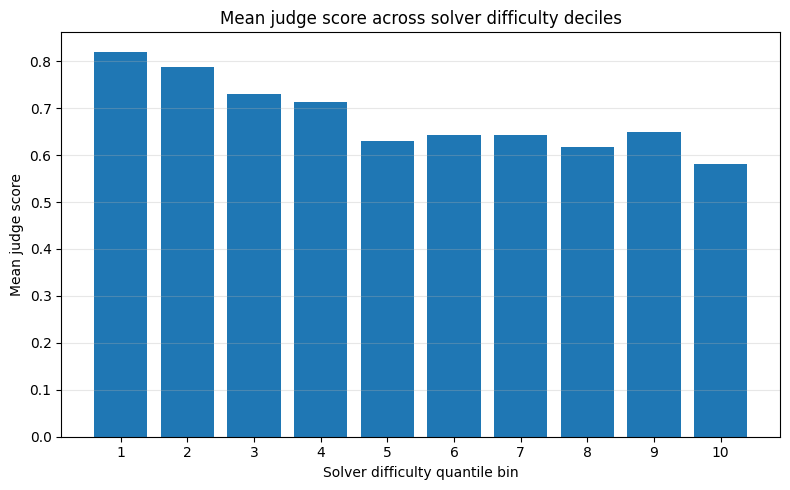

,difficulty_bin,solver_difficulty_mean,judge_score_mean,n_items
0,1,-5.526195,0.820513,39
1,2,-3.225846,0.787081,38
2,3,-1.320538,0.729665,38
3,4,-0.712353,0.712919,38
4,5,-0.096245,0.629187,38
5,6,0.559011,0.643541,38
6,7,0.858246,0.643541,38
7,8,1.294228,0.617225,38
8,9,2.352159,0.648325,38
9,10,5.962960,0.581340,38


In [12]:
import matplotlib.pyplot as plt

plot_df = partone_table.copy()

plot_df["difficulty_bin"] = pd.qcut(
    plot_df["solver_difficulty_centered"],
    q=10,
    labels=False,
    duplicates="drop",
)

bin_summary = (
    plot_df
    .groupby("difficulty_bin", observed=True)
    .agg(
        solver_difficulty_mean=("solver_difficulty_centered", "mean"),
        judge_score_mean=("judge_score_mean", "mean"),
        n_items=("solver_item_id", "count"),
    )
    .reset_index()
)

bin_summary["difficulty_bin"] = bin_summary["difficulty_bin"] + 1

plt.figure(figsize=(8, 5))
plt.bar(
    bin_summary["difficulty_bin"],
    bin_summary["judge_score_mean"],
)
plt.xlabel("Solver difficulty quantile bin")
plt.ylabel("Mean judge score")
plt.title("Mean judge score across solver difficulty deciles")
plt.xticks(bin_summary["difficulty_bin"])
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(out_dir / f"kudge_k{K}_difficulty_bin_summary.png", dpi=300, bbox_inches="tight")
plt.savefig(out_dir / f"kudge_k{K}_difficulty_bin_summary.pdf", bbox_inches="tight")
plt.show()

display(bin_summary)

bin_summary.to_csv(out_dir / f"kudge_k{K}_difficulty_bin_summary.csv", index=False)
bin_summary.to_json(out_dir / f"kudge_k{K}_difficulty_bin_summary.json", orient="records", indent=2, force_ascii=False)


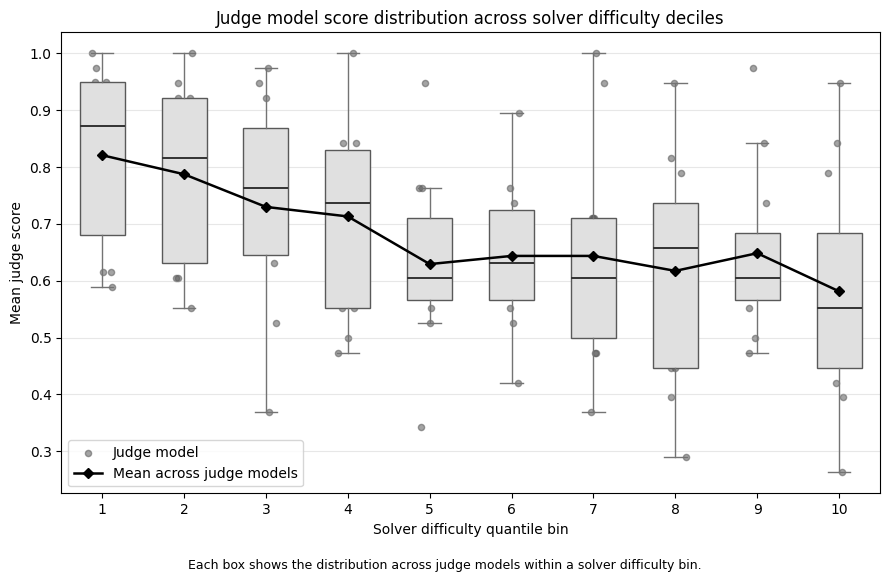

,difficulty_bin,judge_model,judge_score_mean,n_items
0,1,claudehaiku4520251001,0.948718,39
1,1,claudeopus47,1.000000,39
2,1,claudesonnet46,0.974359,39
3,1,ministral14b,0.948718,39
4,1,ministral3b,0.897436,39
...,...,...,...,...
105,10,qwen3508b,0.263158,38
106,10,qwen3527b,0.473684,38
107,10,qwen352b,0.552632,38
108,10,qwen354b,0.394737,38


,difficulty_bin,judge_score_mean,judge_score_sd,n_judge_models
0,1,0.820513,0.155123,11
1,2,0.787081,0.161131,11
2,3,0.729665,0.185742,11
3,4,0.712919,0.170730,11
4,5,0.629187,0.155888,11
5,6,0.643541,0.131244,11
6,7,0.643541,0.197408,11
7,8,0.617225,0.200886,11
8,9,0.648325,0.148991,11
9,10,0.581340,0.205012,11


In [13]:
# Per-judge-model view of Part 1.
# Each box shows the distribution across judge models within a solver difficulty bin.
import numpy as np
model_plot_df = partone_table.copy()
model_plot_df["difficulty_bin"] = pd.qcut(
    model_plot_df["solver_difficulty_centered"],
    q=10,
    labels=False,
    duplicates="drop",
)
model_plot_df["difficulty_bin"] = model_plot_df["difficulty_bin"] + 1

judge_model_rows = []
for _, row in model_plot_df.iterrows():
    scores = row["judge_scores"]
    if not isinstance(scores, dict):
        continue
    for judge_model, score in scores.items():
        if score is None or pd.isna(score):
            continue
        judge_model_rows.append({
            "difficulty_bin": int(row["difficulty_bin"]),
            "solver_item_id": row["solver_item_id"],
            "judge_model": judge_model,
            "judge_score": float(score),
        })

judge_model_scores = pd.DataFrame(judge_model_rows)
judge_model_bin_summary = (
    judge_model_scores
    .groupby(["difficulty_bin", "judge_model"], observed=True)
    .agg(
        judge_score_mean=("judge_score", "mean"),
        n_items=("solver_item_id", "count"),
    )
    .reset_index()
)

judge_model_bin_mean = (
    judge_model_bin_summary
    .groupby("difficulty_bin", observed=True)
    .agg(
        judge_score_mean=("judge_score_mean", "mean"),
        judge_score_sd=("judge_score_mean", "std"),
        n_judge_models=("judge_model", "count"),
    )
    .reset_index()
)

bins = sorted(judge_model_bin_summary["difficulty_bin"].unique())
box_values = [
    judge_model_bin_summary.loc[
        judge_model_bin_summary["difficulty_bin"] == bin_id,
        "judge_score_mean",
    ].dropna().to_numpy()
    for bin_id in bins
]

rng = np.random.default_rng(123)
plot_x = judge_model_bin_summary["difficulty_bin"].to_numpy(dtype=float)
plot_x = plot_x + rng.uniform(-0.14, 0.14, size=len(plot_x))

plt.figure(figsize=(9, 5.8))
plt.boxplot(
    box_values,
    positions=bins,
    widths=0.55,
    patch_artist=True,
    showfliers=False,
    boxprops={"facecolor": "0.88", "edgecolor": "0.35", "linewidth": 1.0},
    medianprops={"color": "0.2", "linewidth": 1.4},
    whiskerprops={"color": "0.45", "linewidth": 1.0},
    capprops={"color": "0.45", "linewidth": 1.0},
)
plt.scatter(
    plot_x,
    judge_model_bin_summary["judge_score_mean"],
    s=20,
    color="0.35",
    alpha=0.55,
    label="Judge model",
)
plt.plot(
    judge_model_bin_mean["difficulty_bin"],
    judge_model_bin_mean["judge_score_mean"],
    color="black",
    marker="D",
    markersize=5,
    linewidth=1.8,
    label="Mean across judge models",
)
plt.xlabel("Solver difficulty quantile bin")
plt.ylabel("Mean judge score")
plt.title("Judge model score distribution across solver difficulty deciles")
plt.xticks(bins)
plt.grid(axis="y", alpha=0.3)
plt.legend(loc="best")
plt.figtext(
    0.5,
    0.01,
    "Each box shows the distribution across judge models within a solver difficulty bin.",
    ha="center",
    fontsize=9,
)
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.savefig(out_dir / f"kudge_k{K}_judge_model_bin_summary.png", dpi=300, bbox_inches="tight")
plt.savefig(out_dir / f"kudge_k{K}_judge_model_bin_summary.pdf", bbox_inches="tight")
plt.show()

display(judge_model_bin_summary)
display(judge_model_bin_mean)

judge_model_bin_summary.to_csv(out_dir / f"kudge_k{K}_judge_model_bin_summary.csv", index=False)
judge_model_bin_summary.to_json(out_dir / f"kudge_k{K}_judge_model_bin_summary.json", orient="records", indent=2, force_ascii=False)
judge_model_bin_mean.to_csv(out_dir / f"kudge_k{K}_judge_model_bin_summary_mean.csv", index=False)
judge_model_bin_mean.to_json(out_dir / f"kudge_k{K}_judge_model_bin_summary_mean.json", orient="records", indent=2, force_ascii=False)


### Part Two

In [14]:
parttwo_table = paired_items[["solver_item_id", 
                      "solver_subset",
                      "solver_difficulty_centered",
                      "solver_difficulty_centered_laplace_se",
                      "solver_gold",
                      "solver_scores",
                      "solver_chosen",
                      "solver_rejected",
                      "judge_difficulty_centered",
                      "judge_difficulty_centered_laplace_se"]]

parttwo_table.to_csv(out_dir / f"kudge_k{K}_parttwo_table_raw.csv", index=False)
parttwo_table.to_json(out_dir / f"kudge_k{K}_parttwo_table_raw.json", orient="records", indent=2, force_ascii=False)


In [15]:
parttwo_table_sorted = parttwo_table.sort_values(
    "solver_difficulty_centered",
    ascending=False,
)

parttwo_table_sorted.to_csv(out_dir / f"kudge_k{K}_parttwo_table_sorted.csv", index=False)
parttwo_table_sorted.to_json(out_dir / f"kudge_k{K}_parttwo_table_sorted.json", orient="records", indent=2, force_ascii=False)


## Solver Difficulty vs Judge Difficulty


Spearman rho: 0.2190
p-value:      1.615e-05


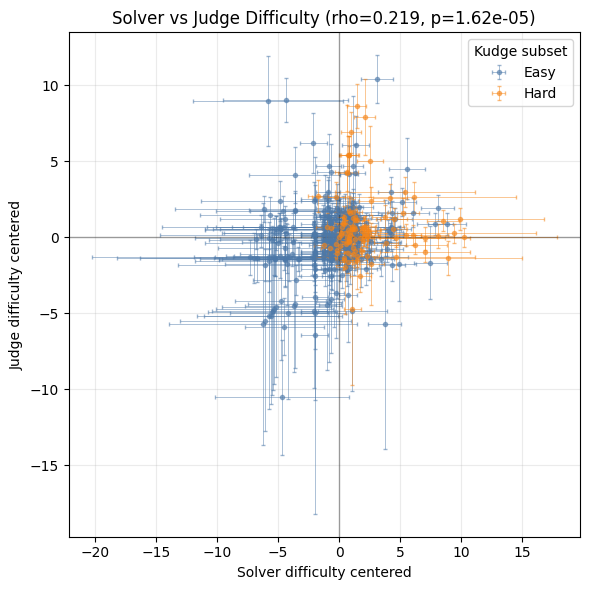

,solver_item_id,solver_subset,solver_difficulty_centered,solver_difficulty_centered_laplace_se,judge_difficulty_centered,judge_difficulty_centered_laplace_se,kudge_split
0,705,Korean-Hard,10.259074,7.561007,-0.016436,0.612976,Hard
1,661,Korean-Hard,9.907616,6.901653,1.185888,0.737823,Hard
2,649,Korean-Hard,9.385316,6.748741,0.249079,0.647955,Hard
3,718,Korean-Hard,8.952496,6.054914,-1.349561,1.120057,Hard
4,8,Korean-Easy,8.862449,1.563285,0.863373,0.728370,Easy


In [16]:
parttwo_difficulty_df = parttwo_table[[
    "solver_item_id",
    "solver_subset",
    "solver_difficulty_centered",
    "solver_difficulty_centered_laplace_se",
    "judge_difficulty_centered",
    "judge_difficulty_centered_laplace_se",
]].dropna().copy()

parttwo_difficulty_df["kudge_split"] = (
    parttwo_difficulty_df["solver_subset"]
    .astype(str)
    .str.replace("Korean-", "", regex=False)
)

raw_rho, raw_p = spearmanr(
    parttwo_difficulty_df["solver_difficulty_centered"],
    parttwo_difficulty_df["judge_difficulty_centered"],
)
print(f"Spearman rho: {raw_rho:.4f}")
print(f"p-value:      {raw_p:.4g}")

colors = {"Easy": "#4C78A8", "Hard": "#F58518"}

plt.figure(figsize=(6, 6))
for split, group in parttwo_difficulty_df.groupby("kudge_split"):
    plt.errorbar(
        group["solver_difficulty_centered"],
        group["judge_difficulty_centered"],
        xerr=group["solver_difficulty_centered_laplace_se"],
        yerr=group["judge_difficulty_centered_laplace_se"],
        fmt="o",
        markersize=3,
        alpha=0.55,
        ecolor=colors.get(split),
        elinewidth=0.6,
        capsize=1.5,
        label=split,
        color=colors.get(split),
    )

plt.axhline(0, color="black", linewidth=1, alpha=0.35)
plt.axvline(0, color="black", linewidth=1, alpha=0.35)
plt.xlabel("Solver difficulty centered")
plt.ylabel("Judge difficulty centered")
plt.title(f"Solver vs Judge Difficulty (rho={raw_rho:.3f}, p={raw_p:.3g})")
plt.legend(title="Kudge subset")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(out_dir / f"kudge_k{K}_solver_judge_difficulty_scatter.png", dpi=300, bbox_inches="tight")
plt.savefig(out_dir / f"kudge_k{K}_solver_judge_difficulty_scatter.pdf", bbox_inches="tight")
plt.show()

display(parttwo_difficulty_df.head())

parttwo_difficulty_df.to_csv(out_dir / f"kudge_k{K}_solver_judge_difficulty_scatter.csv", index=False)
parttwo_difficulty_df.to_json(out_dir / f"kudge_k{K}_solver_judge_difficulty_scatter.json", orient="records", indent=2, force_ascii=False)


## Solver Percentile vs Judge Percentile


Percentile Spearman rho: 0.2190
Percentile p-value:      1.615e-05


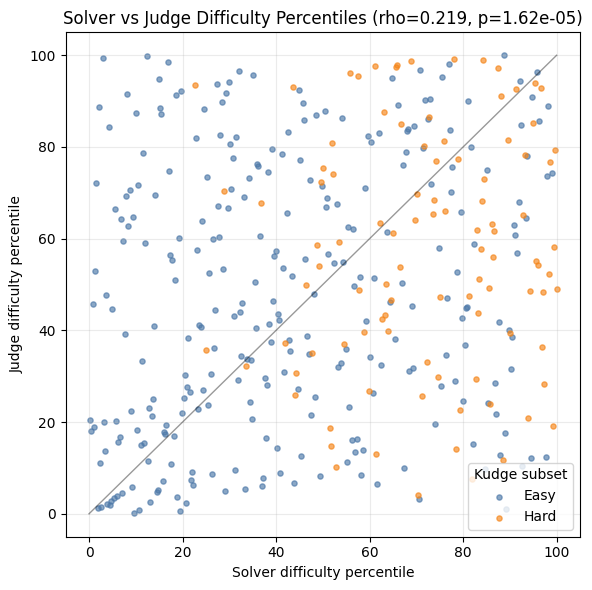

,solver_item_id,solver_subset,solver_difficulty_centered,judge_difficulty_centered,kudge_split,solver_difficulty_percentile,judge_difficulty_percentile
0,705,Korean-Hard,10.259074,-0.016436,Hard,100.000000,49.081365
1,661,Korean-Hard,9.907616,1.185888,Hard,99.737533,79.265092
2,649,Korean-Hard,9.385316,0.249079,Hard,99.475066,58.267717
3,718,Korean-Hard,8.952496,-1.349561,Hard,99.212598,19.160105
4,8,Korean-Easy,8.862449,0.863373,Easy,98.950131,74.278215


In [17]:
percentile_df = paired_items[[
    "solver_item_id",
    "solver_subset",
    "solver_difficulty_centered",
    "judge_difficulty_centered",
]].dropna().copy()

percentile_df["kudge_split"] = (
    percentile_df["solver_subset"]
    .astype(str)
    .str.replace("Korean-", "", regex=False)
)
percentile_df["solver_difficulty_percentile"] = percentile_df["solver_difficulty_centered"].rank(pct=True) * 100
percentile_df["judge_difficulty_percentile"] = percentile_df["judge_difficulty_centered"].rank(pct=True) * 100

pct_rho, pct_p = spearmanr(
    percentile_df["solver_difficulty_percentile"],
    percentile_df["judge_difficulty_percentile"],
)
print(f"Percentile Spearman rho: {pct_rho:.4f}")
print(f"Percentile p-value:      {pct_p:.4g}")

colors = {"Easy": "#4C78A8", "Hard": "#F58518"}

plt.figure(figsize=(6, 6))
for split, group in percentile_df.groupby("kudge_split"):
    plt.scatter(
        group["solver_difficulty_percentile"],
        group["judge_difficulty_percentile"],
        s=14,
        alpha=0.65,
        label=split,
        color=colors.get(split),
    )

plt.plot([0, 100], [0, 100], color="black", linewidth=1, alpha=0.4)
plt.xlabel("Solver difficulty percentile")
plt.ylabel("Judge difficulty percentile")
plt.title(f"Solver vs Judge Difficulty Percentiles (rho={pct_rho:.3f}, p={pct_p:.3g})")
plt.legend(title="Kudge subset")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(out_dir / f"kudge_k{K}_solver_judge_difficulty_percentiles.png", dpi=300, bbox_inches="tight")
plt.savefig(out_dir / f"kudge_k{K}_solver_judge_difficulty_percentiles.pdf", bbox_inches="tight")
plt.show()

display(percentile_df.head())

percentile_df.to_csv(out_dir / f"kudge_k{K}_solver_judge_difficulty_percentiles.csv", index=False)
percentile_df.to_json(out_dir / f"kudge_k{K}_solver_judge_difficulty_percentiles.json", orient="records", indent=2, force_ascii=False)
